In this notebook Seamese network model with contrastive loss+bce for handwriting author verification trained. As backbpn ResNet50 used with freezed parameters.

First, we import our dataset. For training we use handwriting examples from 4 classic datasets: IAM, CEDAR, Bengali и Hindi

In [1]:
#importing dataset
!pip install -q gdown

file_id = "1xpXGz2iJ7VhRG7iSZptX7V5v4dALLhvl"
output_name = "all_data_3.zip"

!gdown --id {file_id} -O {output_name}

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1xpXGz2iJ7VhRG7iSZptX7V5v4dALLhvl
From (redirected): https://drive.google.com/uc?id=1xpXGz2iJ7VhRG7iSZptX7V5v4dALLhvl&confirm=t&uuid=7641ac9f-1443-4abc-a362-e562bb294c06
To: /content/all_data_3.zip
100% 1.76G/1.76G [00:18<00:00, 93.5MB/s]


In [2]:
import zipfile
import os

with zipfile.ZipFile("all_data_3.zip", 'r') as zip_ref:
    zip_ref.extractall("/kaggle/working/")

# Посмотрите, что получилось
os.listdir("/kaggle/working/")

['all_data_3']

In [3]:
DATA_ROOT = "/kaggle/working/all_data_3"

In [4]:
!pip install torchvision

In [7]:
import os
from pathlib import Path
import cv2
import numpy as np
import shutil
import random
import torch

from torch.utils.data import Dataset
import PIL
from PIL import Image
import torchvision.transforms as T
import torchvision.transforms.functional as TF
from torch.utils.data import DataLoader

import torch.nn as nn
import torchvision.models as models
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
import torch.nn.functional as F
from sklearn.metrics import roc_auc_score
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.metrics import roc_curve, roc_auc_score, accuracy_score

In [8]:
def set_seed(seed=42):
    """Fix all random seeds for reproducibility"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)
    print(f"All seeds fixed to {seed}")
set_seed(42)

All seeds fixed to 42


Let's create class Pairs_Dataset for our data.
The dataset takes random pairs and create either positive (one author/two genuine signatures pf one author) or negative pair (two different authors/genuine and forgery of the sameauthor). The labels are created at random, the balance shall be ~50/50.
The pairs are created 'on the fly'.

In [ ]:
class Pairs_Dataset(Dataset):
    def __init__(self, root, transform=None, size=100,
                 authors_list=None, iam_ratio=0.5):
        """
        Dataset for Siamese Network with Contrastive Loss.
        Supports IAM (handwriting lines), CEDAR, Bengali, Hindi (signatures with forgeries).

        Args:
            root: Root directory containing 'iam', 'cedar', 'bengali', 'hindi' folders
            transform: Image transformations
            size: Number of pairs per epoch
            authors_list: List of author IDs to include (for train/val split)
            iam_ratio: Probability of sampling from IAM (0.5 = 50% IAM)
        """
        self.transform = transform
        self.size = size
        self.iam_ratio = iam_ratio

        # Data structures
        self.iam_data = {}
        self.cedar_original = {}
        self.cedar_forgery = {}
        self.bengali_original = {}
        self.bengali_forgery = {}
        self.hindi_original = {}
        self.hindi_forgery = {}

        #Scan IAM folder
        iam_path = os.path.join(root, 'iam')
        if os.path.exists(iam_path):
            for folder in os.listdir(iam_path):
                author_path = os.path.join(iam_path, folder)
                if not os.path.isdir(author_path):
                    continue

                author_id = folder
                valid_images = []
                for file in os.listdir(author_path):
                    if not file.lower().endswith(('.png', '.jpg', '.jpeg')):
                        continue

                    img_path = os.path.join(author_path, file)
                    try:
                        with Image.open(img_path) as img:
                            img.verify()  
                        valid_images.append(img_path)
                    except Exception:
                        continue

                if valid_images:
                    self.iam_data[author_id] = valid_images

        #Scan CEDAR folder
        cedar_path = os.path.join(root, 'cedar')
        if os.path.exists(cedar_path):
            cedar_original_path = os.path.join(cedar_path, 'original')
            if os.path.exists(cedar_original_path):
                for author_id in os.listdir(cedar_original_path):
                    author_path = os.path.join(cedar_original_path, author_id)
                    if not os.path.isdir(author_path):
                        continue

                    valid_images = []
                    for file in os.listdir(author_path):
                        if not file.lower().endswith(('.png', '.jpg', '.jpeg', '.tif', '.tiff')):
                            continue
                        img_path = os.path.join(author_path, file)
                        try:
                            with Image.open(img_path) as img:
                                img.verify()
                            valid_images.append(img_path)
                        except Exception:
                            continue

                    if valid_images:
                        self.cedar_original[author_id] = valid_images

            cedar_forgery_path = os.path.join(cedar_path, 'forgery')
            if os.path.exists(cedar_forgery_path):
                for author_id in os.listdir(cedar_forgery_path):
                    author_path = os.path.join(cedar_forgery_path, author_id)
                    if not os.path.isdir(author_path):
                        continue

                    valid_images = []
                    for file in os.listdir(author_path):
                        if not file.lower().endswith(('.png', '.jpg', '.jpeg', '.tif', '.tiff')):
                            continue
                        img_path = os.path.join(author_path, file)
                        try:
                            with Image.open(img_path) as img:
                                img.verify()
                            valid_images.append(img_path)
                        except Exception:
                            continue

                    if valid_images:
                        self.cedar_forgery[author_id] = valid_images

        #Scan Bengali folder
        bengali_path = os.path.join(root, 'bengali')
        if os.path.exists(bengali_path):
            for author_id in os.listdir(bengali_path):
                author_path = os.path.join(bengali_path, author_id)
                if not os.path.isdir(author_path):
                    continue

                genuine_path = os.path.join(author_path, 'genuine')
                if os.path.exists(genuine_path):
                    valid_images = []
                    for file in os.listdir(genuine_path):
                        if not file.lower().endswith(('.png', '.jpg', '.jpeg', '.tif', '.tiff')):
                            continue
                        img_path = os.path.join(genuine_path, file)
                        try:
                            with Image.open(img_path) as img:
                                img.verify()
                            valid_images.append(img_path)
                        except Exception:
                            continue
                    if valid_images:
                        self.bengali_original[author_id] = valid_images

                forge_path = os.path.join(author_path, 'forge')
                if os.path.exists(forge_path):
                    valid_images = []
                    for file in os.listdir(forge_path):
                        if not file.lower().endswith(('.png', '.jpg', '.jpeg', '.tif', '.tiff')):
                            continue
                        img_path = os.path.join(forge_path, file)
                        try:
                            with Image.open(img_path) as img:
                                img.verify()
                            valid_images.append(img_path)
                        except Exception:
                            continue
                    if valid_images:
                        self.bengali_forgery[author_id] = valid_images

        #Scan Hindi folder
        hindi_path = os.path.join(root, 'hindi')
        if os.path.exists(hindi_path):
            for author_id in os.listdir(hindi_path):
                author_path = os.path.join(hindi_path, author_id)
                if not os.path.isdir(author_path):
                    continue

                genuine_path = os.path.join(author_path, 'genuine')
                if os.path.exists(genuine_path):
                    valid_images = []
                    for file in os.listdir(genuine_path):
                        if not file.lower().endswith(('.png', '.jpg', '.jpeg', '.tif', '.tiff')):
                            continue
                        img_path = os.path.join(genuine_path, file)
                        try:
                            with Image.open(img_path) as img:
                                img.verify()
                            valid_images.append(img_path)
                        except Exception:
                            continue
                    if valid_images:
                        self.hindi_original[author_id] = valid_images

                forge_path = os.path.join(author_path, 'forge')
                if os.path.exists(forge_path):
                    valid_images = []
                    for file in os.listdir(forge_path):
                        if not file.lower().endswith(('.png', '.jpg', '.jpeg', '.tif', '.tiff')):
                            continue
                        img_path = os.path.join(forge_path, file)
                        try:
                            with Image.open(img_path) as img:
                                img.verify()
                            valid_images.append(img_path)
                        except Exception:
                            continue
                    if valid_images:
                        self.hindi_forgery[author_id] = valid_images

        #Filter by author's list
        author_set = set(authors_list)
        self.iam_data = {k: v for k, v in self.iam_data.items() if k in author_set}
        self.cedar_original = {k: v for k, v in self.cedar_original.items() if k in author_set}
        self.cedar_forgery = {k: v for k, v in self.cedar_forgery.items() if k in author_set}
        self.bengali_original = {k: v for k, v in self.bengali_original.items() if k in author_set}
        self.bengali_forgery = {k: v for k, v in self.bengali_forgery.items() if k in author_set}
        self.hindi_original = {k: v for k, v in self.hindi_original.items() if k in author_set}
        self.hindi_forgery = {k: v for k, v in self.hindi_forgery.items() if k in author_set}

        # Build author lists
        self.iam_authors = [a for a, imgs in self.iam_data.items() if len(imgs) >= 2]
        self.iam_all_authors = list(self.iam_data.keys())

        def build_signature_lists(original_dict, forgery_dict):
            authors_with_original = [a for a, imgs in original_dict.items() if len(imgs) >= 2]
            authors_with_forgery = [a for a in original_dict.keys()
                                     if a in forgery_dict
                                     and len(original_dict[a]) >= 1
                                     and len(forgery_dict[a]) >= 1]
            all_authors = list(original_dict.keys())
            return authors_with_original, authors_with_forgery, all_authors

        self.cedar_authors, self.cedar_authors_with_forgery, self.cedar_all_authors = build_signature_lists(self.cedar_original, self.cedar_forgery)
        self.bengali_authors, self.bengali_authors_with_forgery, self.bengali_all_authors = build_signature_lists(self.bengali_original, self.bengali_forgery)
        self.hindi_authors, self.hindi_authors_with_forgery, self.hindi_all_authors = build_signature_lists(self.hindi_original, self.hindi_forgery)

        # Combine signature datasets
        self.signature_datasets = []
        if self.cedar_authors or self.cedar_authors_with_forgery:
            self.signature_datasets.append(('cedar', self.cedar_original, self.cedar_forgery,
                                           self.cedar_authors, self.cedar_authors_with_forgery, self.cedar_all_authors))
        if self.bengali_authors or self.bengali_authors_with_forgery:
            self.signature_datasets.append(('bengali', self.bengali_original, self.bengali_forgery,
                                           self.bengali_authors, self.bengali_authors_with_forgery, self.bengali_all_authors))
        if self.hindi_authors or self.hindi_authors_with_forgery:
            self.signature_datasets.append(('hindi', self.hindi_original, self.hindi_forgery,
                                           self.hindi_authors, self.hindi_authors_with_forgery, self.hindi_all_authors))


    def __len__(self):
        return self.size

    def _get_iam_pair(self, label):
        """IAM: positive=same author, negative=different authors"""
        if label == 1:
            author = random.choice(self.iam_authors)
            images = self.iam_data[author]
            if len(images) < 2:
                return None, None, None
            img1_path, img2_path = random.sample(images, 2)
        else:
            if len(self.iam_all_authors) < 2:
                return None, None, None
            author1, author2 = random.sample(self.iam_all_authors, 2)
            img1_path = random.choice(self.iam_data[author1])
            img2_path = random.choice(self.iam_data[author2])
        return img1_path, img2_path, label

    def _get_signature_pair(self, dataset_name, original_dict, forgery_dict,
                           authors, authors_with_forgery, all_authors, label):
        """
        Signature datasets (CEDAR, Bengali, Hindi):
        - Positive: 2 genuine 
        - Negative: 1 genuine + 1 forgery 
        """
        if label == 1:
            author = random.choice(authors)
            original_images = original_dict[author]
            if len(original_images) < 2:
                return None, None, None
            img1_path, img2_path = random.sample(original_images, 2)
        else:
            # Negative
            author = random.choice(authors_with_forgery)
            original_images = original_dict[author]
            forgery_images = forgery_dict[author]

            img1_path = random.choice(original_images)
            img2_path = random.choice(forgery_images)

        return img1_path, img2_path, label

    def __getitem__(self, idx):
        use_iam = random.random() < self.iam_ratio
        label = random.randint(0, 1)

        img1_path, img2_path, final_label = None, None, None

        if use_iam and self.iam_authors:
            img1_path, img2_path, final_label = self._get_iam_pair(label)

        if img1_path is None and self.signature_datasets:
            dataset_name, original_dict, forgery_dict, authors, authors_with_forgery, all_authors = random.choice(self.signature_datasets)
            result = self._get_signature_pair(dataset_name, original_dict, forgery_dict,
                                              authors, authors_with_forgery, all_authors, label)
            img1_path, img2_path, final_label = result

        if img1_path is None:
            # Fallback: try any available dataset
            if self.iam_authors:
                img1_path, img2_path, final_label = self._get_iam_pair(1)
            elif self.signature_datasets:
                dataset_name, original_dict, forgery_dict, authors, authors_with_forgery, all_authors = random.choice(self.signature_datasets)
                result = self._get_signature_pair(dataset_name, original_dict, forgery_dict,
                                                  authors, authors_with_forgery, all_authors, 1)
                img1_path, img2_path, final_label = result

        img1 = Image.open(img1_path).convert('L')
        img2 = Image.open(img2_path).convert('L')

        if self.transform:
            img1 = self.transform(img1)
            img2 = self.transform(img2)

        return img1, img2, final_label, img1_path, img2_path

Use train, val, test authors generated previously

In [ ]:
train_authors=['353', '662', '546', '181', '126', '104', '15', '72', '629', '094', '10', '139', '090', '636', '160', '092', '136', '328', '190', '20', '392', '652',
               '5', '405', '378', '236', '650', '573', '162', '349', '515', '59', '128', '421', '48', '14', '3', '262', '454', '670', '281', '543', '435', '632', '393',
               '192', '594', '237', '270', '250', '153', '320', '6', '531', '418', '399', '460', '603', '027', '598', '276', '083', '216', '391', '131', '2', '496', '53',
               '618', '093', '318', '214', '189', '110', '425', '389', '420', '401', '32', '562', '170', '93', '609', '616', '357', '597', '80', '626', '332', '119', '060',
               '487', '025', '547', '390', '513', '147', '072', '553', '183', '623', '615', '500', '198', '011', '174', '647', '664', '278', '445', '290', '210', '272',
               '448', '503', '534', '69', '88', '68', '120', '24', '464', '398', '568', '070', '610', '628', '591', '31', '529', '215', '149', '138', '118', '451', '572',
               '17', '339', '049', '25', '60', '26', '243', '054', '032', '586', '471', '377', '342', '87', '58', '620', '179', '89', '109', '304', '034', '365', '373',
               '363', '169', '071', '49', '579', '382', '444', '412', '485', '310', '473', '619', '084', '518', '535', '144', '542', '280', '145', '520', '156', '099',
               '576', '570', '589', '059', '595', '208', '361', '307', '558', '101', '67', '030', '38', '115', '19', '371', '340', '567', '319', '352', '274', '530',
               '102', '259', '555', '525', '462', '226', '27', '539', '041', '607', '508', '344', '182', '79', '288', '085', '095', '239', '267', '584', '92', '639',
               '410', '70', '184', '121', '492', '114', '509', '053', '334', '246', '490', '449', '255', '440', '185', '580', '294', '477', '495', '436', '291', '641',
               '33', '35', '21', '089', '103', '289', '370', '221', '466', '242', '076', '423', '379', '020', '008', '224', '019', '248', '98', '067', '483', '37', '663',
               '064', '582', '086', '031', '23', '563', '611', '305', '96', '472', '283', '043', '414', '141', '34', '151', '065', '621', '55', '91', '260', '231', '048',
               '478', '499', '606', '056', '354', '229', '045', '81', '096', '343', '408', '264', '155', '596', '253', '461', '235', '042', '73', '347', '482', '475',
               '386', '197', '394', '431', '65', '634', '416', '90', '36', '303', '122', '018', '517', '668', '252', '097', '228', '107', '413', '082', '556', '203',
               '494', '285', '028', '191', '592', '256', '578', '171', '002', '188', '526', '367', '116', '522', '234', '71', '30', '035', '364', '268', '327', '484',
               '146', '312', '533', '4', '046', '209', '433', '86', '402', '350', '640', '428', '453', '279', '536', '441', '037', '614', '47', '296', '159', '315', '062',
               '000', '407', '549', '080', '335', '079', '504', '659', '419', '117', '540', '081', '452', '351', '521', '384', '051', '648', '524', '036', '411', '75',
               '645', '325', '559', '211', '583', '527', '1', '502', '447', '7', '193', '565', '99', '152', '551', '608', '403', '195', '298', '006', '004', '077',
               '187', '301', '491', '366', '130', '538', '206', '324', '175', '098', '247', '180', '222', '251', '28', '63', '474', '671', '545', '088', '052', '388',
               '257', '123', '172', '486', '83', '554', '41', '417', '430', '660', '023', '56', '380', '40', '227', '566', '026', '219', '481', '575', '309', '489', '638',
               '148', '45', '258', '249', '200', '356', '331', '263', '232', '630', '063', '164', '544', '168', '359', '443', '047', '186', '85', '470', '336', '176',
               '078', '651', '196', '577', '455', '012', '666', '571', '317', '376', '429', '655', '314', '52', '600', '058', '212', '016', '022', '217', '94', '106',
               '44', '244', '77', '199', '8', '329', '22', '519', '561', '643', '64', '137', '501', '493']
val_authors=['456', '9', '426', '97', '322', '133', '13', '021', '157', '355', '166', '375', '627', '345', '605', '140', '135', '161', '163', '593', '476', '84', '225',
             '223', '62', '213', '512', '266', '537', '446', '100', '346', '422', '233', '613', '167', '261', '360', '127', '633', '292', '442', '341', '564', '468',
             '654', '467', '302', '330', '220', '465', '458', '18', '299', '326', '286', '014', '528', '635', '007', '569', '548', '333', '57', '207', '581', '039',
             '50', '338', '439', '205', '54', '552', '173', '348', '644', '488', '665', '362', '498', '409', '637', '587', '075', '300', '108', '642', '74', '400',
             '76', '074', '125', '51', '091', '017', '295', '245', '624', '142', '383', '585', '457', '230', '040', '497', '073', '432', '369', '275', '506', '201',
             '241', '129', '218']
test_authors=['43', '134', '516', '055', '204', '313', '523', '068', '404', '372', '601', '395', '469', '617', '009', '254', '588', '194', '337', '178', '511', '29',
              '015', '82', '287', '124', '599', '112', '39', '541', '293', '010', '143', '625', '132', '95', '158', '649', '622', '316', '282', '667', '532', '321',
              '177', '013', '505', '297', '631', '42', '658', '66', '368', '202', '510', '590', '165', '459', '154', '434', '61', '005', '397', '105', '602', '265',
              '46', '396', '387', '450', '323', '001', '087', '240', '113', '066', '604', '044', '061', '550', '463', '653', '033', '273', '669', '514', '150', '024',
              '424', '479', '069', '16', '574', '308', '238', '038', '415', '560', '385', '557', '277', '480', '612', '661', '111', '12', '427', '78', '050', '003',
              '269', '11', '406', '029']


In [9]:
train_transform = T.Compose([
    T.Resize((224, 224)),  #use 224*224 for the model
    T.RandomRotation(3),
    T.RandomAffine(0, translate=(0.02, 0.02), scale=(0.98, 1.02)),
    T.ToTensor(),
    T.Normalize(0.485, 0.229)
])

val_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(0.485, 0.229)
])

test_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(0.485, 0.229)
])

In [ ]:
train_dataset = Pairs_Dataset(
    root=DATA_ROOT,
    transform=train_transform,
    train=True,
    size=5000,
    authors_list=train_authors
)

In [10]:
class SavedPairsDataset(Dataset):
    def __init__(self, pairs_file, transform=None):
        with open(pairs_file, 'rb') as f:
            self.pairs = pickle.load(f)
        self.transform = transform

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img1_path, img2_path, label = self.pairs[idx]

        img1 = Image.open(img1_path).convert('L')
        img2 = Image.open(img2_path).convert('L')

        if self.transform:
            img1 = self.transform(img1)
            img2 = self.transform(img2)

        return img1, img2, label

In [ ]:

# val_pairs = []
# test_pairs = []
# temp_dataset_val = Pairs_Dataset(root=DATA_ROOT, transform=None, train=False,
#                               size=2000, authors_list=val_authors)
# temp_dataset_test = Pairs_Dataset(root=DATA_ROOT, transform=None, train=False,
#                               size=1000, authors_list=test_authors)
# for i in range(len(temp_dataset_val)):
#     img1, img2, label, p1, p2 = temp_dataset_val[i]
#     val_pairs.append((p1, p2, label))

# for i in range(len(temp_dataset_test)):
#     img1, img2, label, p1, p2 = temp_dataset_test[i]
#     test_pairs.append((p1, p2, label))

# with open('val_pairs.pkl', 'wb') as f:
#     pickle.dump(val_pairs, f)

# with open('test_pairs.pkl', 'wb') as f:
#     pickle.dump(test_pairs, f)

# Загрузка
val_dataset = SavedPairsDataset('val_pairs.pkl', transform=val_transform)
test_dataset = SavedPairsDataset('test_pairs.pkl', transform=test_transform)

Label: 0
Size img1: torch.Size([1, 224, 224])
Size img2: torch.Size([1, 224, 224])


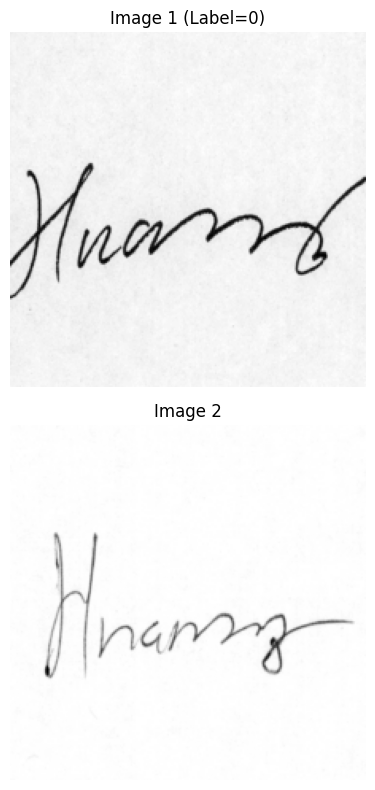

In [ ]:
img1, img2, label = val_dataset[0]

print(f"Label: {label}")
print(f"Size img1: {img1.shape}")
print(f"Size img2: {img2.shape}")

plt.figure(figsize=(10, 8))

plt.subplot(2, 1, 1)
plt.imshow(img1[0], cmap='gray')
plt.title(f"Image 1 (Label={label})")
plt.axis('off')

plt.subplot(2, 1, 2)
plt.imshow(img2[0], cmap='gray')
plt.title("Image 2")
plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
labels=[]

for i in range(len(train_dataset)):
  labels.append(train_dataset[i][2])

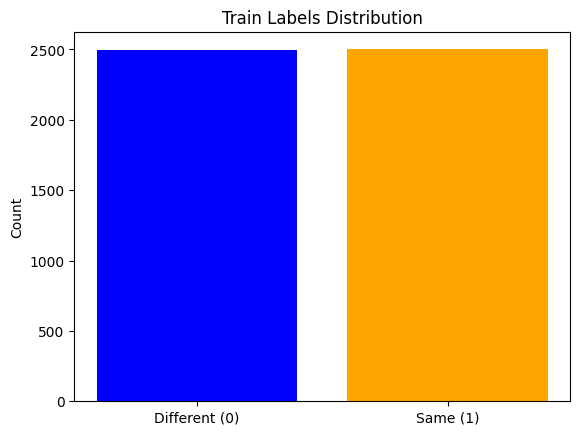

In [ ]:
counts = [labels.count(0), labels.count(1)]

plt.bar(['Different (0)', 'Same (1)'], counts, color=['blue', 'orange'])
plt.ylabel('Count')
plt.title('Train Labels Distribution')
plt.show()

In [ ]:
# creating DataLoader
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

Let's create class for our model. The class has freeze_mode parameter (aggressive or moderate), in aggressive mode we freeze all layer except for the last one (layer4), in moderate except for 2 lasts (layer3 and 4layers). After embedding head, trainable classification head added, for training we use Contrastive loss+BCE. To calculate accuracy threshold 0.5 taken

In [11]:
class SiameseNetwork(nn.Module):
    def __init__(self, embedding_size=256, freeze_mode="aggressive"):
        super(SiameseNetwork, self).__init__()

        # Load pretrained ResNet-50
        backbone = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

        # Adapt first layer for single channel
        original_conv1 = backbone.conv1
        backbone.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        backbone.conv1.weight.data = original_conv1.weight.data.mean(dim=1, keepdim=True)

        # Remove final FC layer
        self.resnet = nn.Sequential(*list(backbone.children())[:-1])

        # Freeze layers based on mode
        if freeze_mode == "aggressive":
            # Freeze all layers
            for param in self.resnet.parameters():
                param.requires_grad = False

            # Unfreeze layer4 (index 7) and conv1 (index 0)
            # layer4 parameters are under index 7
            for name, param in self.resnet.named_parameters():
                if name.startswith('7.'):  # layer4
                    param.requires_grad = True

            # Unfreeze conv1 (index 0)
            for param in self.resnet[0].parameters():
                param.requires_grad = True

        elif freeze_mode == "moderate":
            # Freeze all layers first
            for param in self.resnet.parameters():
                param.requires_grad = False

            # Unfreeze layer3 (index 6) and layer4 (index 7)
            for name, param in self.resnet.named_parameters():
                if name.startswith('6.') or name.startswith('7.'):  # layer3 and layer4
                    param.requires_grad = True

            # Unfreeze conv1 (index 0)
            for param in self.resnet[0].parameters():
                param.requires_grad = True

        elif freeze_mode == "none":
            # All layers trainable
            pass

        # Embedding head
        self.embedding = nn.Sequential(
            nn.Linear(2048, 1024),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(1024, embedding_size)
        )

        # Classifier head
        self.classifier = nn.Linear(embedding_size, 1)

        self.embedding_size = embedding_size

        # Print statistics
        total = sum(p.numel() for p in self.parameters())
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f"Freeze mode: {freeze_mode}")
        print(f"Total parameters: {total:,}")
        print(f"Trainable parameters: {trainable:,} ({100*trainable/total:.1f}%)")

    def forward_one(self, x):
        x = self.resnet(x)
        x = x.view(x.size(0), -1)
        x = self.embedding(x)
        return F.normalize(x, p=2, dim=1)

    def forward(self, x1, x2):
        out1 = self.forward_one(x1)
        out2 = self.forward_one(x2)
        distance = torch.abs(out1 - out2)
        logits = self.classifier(distance).squeeze(1)
        return logits, out1, out2

In [ ]:
class ContrastiveLoss(nn.Module):
    """Contrastive loss"""

    def __init__(self, margin=1.0):
        super(ContrastiveLoss, self).__init__()
        self.margin = margin

    def forward(self, output1, output2, label):
        # Eucledian distance
        distance = F.pairwise_distance(output1, output2)

        loss = label * torch.pow(distance, 2) / 2
        loss += (1 - label) * torch.pow(torch.clamp(self.margin - distance, min=0.0), 2) / 2

        return loss.mean()

In [12]:
def calculate_eer(labels, scores):
    """
    Calculate Equal Error Rate (EER)

    Args:
        labels: true labels (0 or 1)
        scores: predicted probabilities

    Returns:
        eer: Equal Error Rate
    """
    fpr, tpr, thresholds = roc_curve(labels, scores)
    fnr = 1 - tpr

    # Find the threshold where FPR and FNR are closest
    eer_idx = np.nanargmin(np.absolute(fnr - fpr))
    eer = (fpr[eer_idx] + fnr[eer_idx]) / 2

    return eer

def train_model(
    model,
    train_loader,
    val_loader,
    epochs=50,
    lr=0.001,
    device=None,
    save_path='best_model.pth',
    weight_decay=0.01
):
    """Training Siamese network with fixed contrastive loss"""

    # Move model to device
    model = model.to(device)

    # Optimizer and scheduler
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=2, threshold = 0.01
    )

    # Loss functions
    contrastive_loss = ContrastiveLoss(margin=1.0)
    bce_loss = nn.BCEWithLogitsLoss()

    # History tracking
    history = {
        'train_loss': [], 'val_loss': [],
        'train_acc': [], 'val_acc': [],
        'train_roc_auc': [], 'val_roc_auc': [],
        'train_eer': [], 'val_eer': [],
        'lr': []
    }
    best_val_roc_auc = 0.0

    for epoch in range(epochs):
        # training
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0
        train_labels = []
        train_preds = []


        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]")
        for img1, img2, labels in pbar:
            img1 = img1.to(device)
            img2 = img2.to(device)
            labels = labels.float().to(device)

            optimizer.zero_grad()
            logits, emb1, emb2 = model(img1, img2)

            loss_contrastive = contrastive_loss(emb1, emb2, labels)
            loss_bce = bce_loss(logits, labels)
            loss = loss_contrastive+loss_bce #used mixed loss

            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            probs = torch.sigmoid(logits)
            predicted = (probs > 0.5).float()
            train_correct += (predicted == labels).sum().item()
            train_total += labels.size(0)

            train_labels.extend(labels.cpu().numpy())
            train_preds.extend(probs.detach().cpu().numpy())  

            pbar.set_postfix({
                'loss': f'{loss.item():.4f}',
                'acc': f'{train_correct/train_total:.3f}'
                }
            )

        train_acc = train_correct / train_total
        train_loss_avg = train_loss / len(train_loader)
        train_roc_auc = roc_auc_score(train_labels, train_preds)
        train_eer = calculate_eer(train_labels, train_preds)


        # Validation
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        val_labels = []
        val_preds = []


        with torch.no_grad():
            for img1, img2, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]"):
                img1 = img1.to(device)
                img2 = img2.to(device)
                labels = labels.float().to(device)

                logits, emb1, emb2 = model(img1, img2)

                loss_contrastive = contrastive_loss(emb1, emb2, labels)
                loss_bce = bce_loss(logits, labels)
                loss = loss_contrastive+loss_bce

                val_loss += loss.item()

                probs = torch.sigmoid(logits)
                predicted = (probs > 0.5).float()
                val_correct += (predicted == labels).sum().item()
                val_total += labels.size(0)

                val_labels.extend(labels.cpu().numpy())
                val_preds.extend(probs.cpu().numpy())

        val_acc = val_correct / val_total
        val_loss_avg = val_loss / len(val_loader)
        val_roc_auc = roc_auc_score(val_labels, val_preds)
        val_eer = calculate_eer(val_labels, val_preds)

        # Update scheduler
        scheduler.step(val_loss_avg)

        # Save history
        history['train_loss'].append(train_loss_avg)
        history['val_loss'].append(val_loss_avg)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['train_roc_auc'].append(train_roc_auc)
        history['val_roc_auc'].append(val_roc_auc)
        history['train_eer'].append(train_eer)
        history['val_eer'].append(val_eer)
        history['lr'].append(optimizer.param_groups[0]['lr'])

        # Print results
        print(f"\nEpoch {epoch+1}/{epochs}")
        print(f"  Train Loss: {train_loss_avg:.4f}, Train Acc: {train_acc:.4f}, ROC-AUC: {train_roc_auc:.4f}, EER: {train_eer:.4f}")
        print(f"  Val Loss:   {val_loss_avg:.4f}, Val Acc:   {val_acc:.4f}, ROC-AUC: {val_roc_auc:.4f}, EER: {val_eer:.4f}")
        print(f"  LR: {optimizer.param_groups[0]['lr']:.6f}")

        # Save best model by ROC-AUC
        if val_roc_auc > best_val_roc_auc:
            best_val_roc_auc = val_roc_auc
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_acc': val_acc,
                'val_roc_auc': val_roc_auc,
                'val_eer': val_eer
            }, save_path)
            print(f"Model saved. Val Acc: {val_acc:.4f}, Val ROC-AUC: {val_roc_auc:.4f}, Val EER: {val_eer:.4f}")

    return history

In [ ]:
model_agr_freezed = SiameseNetwork(embedding_size=256, freeze_mode='aggressive')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# Train
history_agr_freezed = train_model(
    model=model_agr_freezed,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=30,
    lr=0.001,
    device=device,
    save_path='best_model_agr_freezed_c+b.pth',
    weight_decay=0.0001)

print(f"\nBest Val ROC-AUC: {max(history_agr_freezed['val_roc_auc'])*100:.2f}%")

Freeze mode: aggressive
Total parameters: 25,862,593
Trainable parameters: 17,328,705 (67.0%)


Epoch 1/30 [Val]: 100%|██████████| 250/250 [00:31<00:00,  8.04it/s]



Epoch 1/30
  Train Loss: 0.7945, Train Acc: 0.5340, ROC-AUC: 0.5948, EER: 0.4362
  Val Loss:   0.7179, Val Acc:   0.6710, ROC-AUC: 0.8002, EER: 0.2850
  LR: 0.001000
Model saved. Val Acc: 0.6710, Val ROC-AUC: 0.8002, Val EER: 0.2850


Epoch 2/30 [Val]: 100%|██████████| 250/250 [00:28<00:00,  8.64it/s]



Epoch 2/30
  Train Loss: 0.7232, Train Acc: 0.6764, ROC-AUC: 0.7263, EER: 0.3308
  Val Loss:   0.6939, Val Acc:   0.7170, ROC-AUC: 0.7930, EER: 0.2775
  LR: 0.001000


...


Epoch 28/30
  Train Loss: 0.4242, Train Acc: 0.8434, ROC-AUC: 0.9178, EER: 0.1696
  Val Loss:   0.5022, Val Acc:   0.8220, ROC-AUC: 0.9126, EER: 0.1615
  LR: 0.000031


Epoch 29/30 [Val]: 100%|██████████| 250/250 [00:28<00:00,  8.66it/s]



Epoch 29/30
  Train Loss: 0.4399, Train Acc: 0.8278, ROC-AUC: 0.9105, EER: 0.1844
  Val Loss:   0.5008, Val Acc:   0.8150, ROC-AUC: 0.9157, EER: 0.1650
  LR: 0.000031


Epoch 30/30 [Val]: 100%|██████████| 250/250 [00:28<00:00,  8.78it/s]



Epoch 30/30
  Train Loss: 0.4471, Train Acc: 0.8210, ROC-AUC: 0.9092, EER: 0.1854
  Val Loss:   0.5016, Val Acc:   0.8155, ROC-AUC: 0.9123, EER: 0.1665
  LR: 0.000016

Best Val ROC-AUC: 91.81%


In [ ]:
history_agr_freezed

{'train_loss': [0.794500660610199,
  0.7232231364250183,
  0.6600374130249024,
  0.6355331231594086,
  0.6267173874139785,
  0.6144562472581864,
  0.5878488359451294,
  0.5808371461629868,
  0.5689392104387283,
  0.5630450423717499,
  0.5374157950401306,
  0.520151234126091,
  0.5050886075615882,
  0.500951578938961,
  0.4945074229955673,
  0.4888763165473938,
  0.47505818457603455,
  0.4668250912308693,
  0.4705720165014267,
  0.46226999638080596,
  0.4514379827439785,
  0.45748186606168745,
  0.43178228313922884,
  0.4587626163005829,
  0.45009065561294553,
  0.43561169930696486,
  0.4458794865369797,
  0.42417564836144445,
  0.43988567863702777,
  0.44713592814207076],
 'val_loss': [0.7179065241813659,
  0.6938987990617752,
  0.8094168381690979,
  0.9332306665182114,
  0.6661345534324646,
  0.653079607963562,
  0.5685414263010025,
  0.5854739079475403,
  0.5856100398898124,
  0.6580598500967025,
  0.5760675511956215,
  0.5226711147427558,
  0.5615457299947738,
  0.5261637771725655,


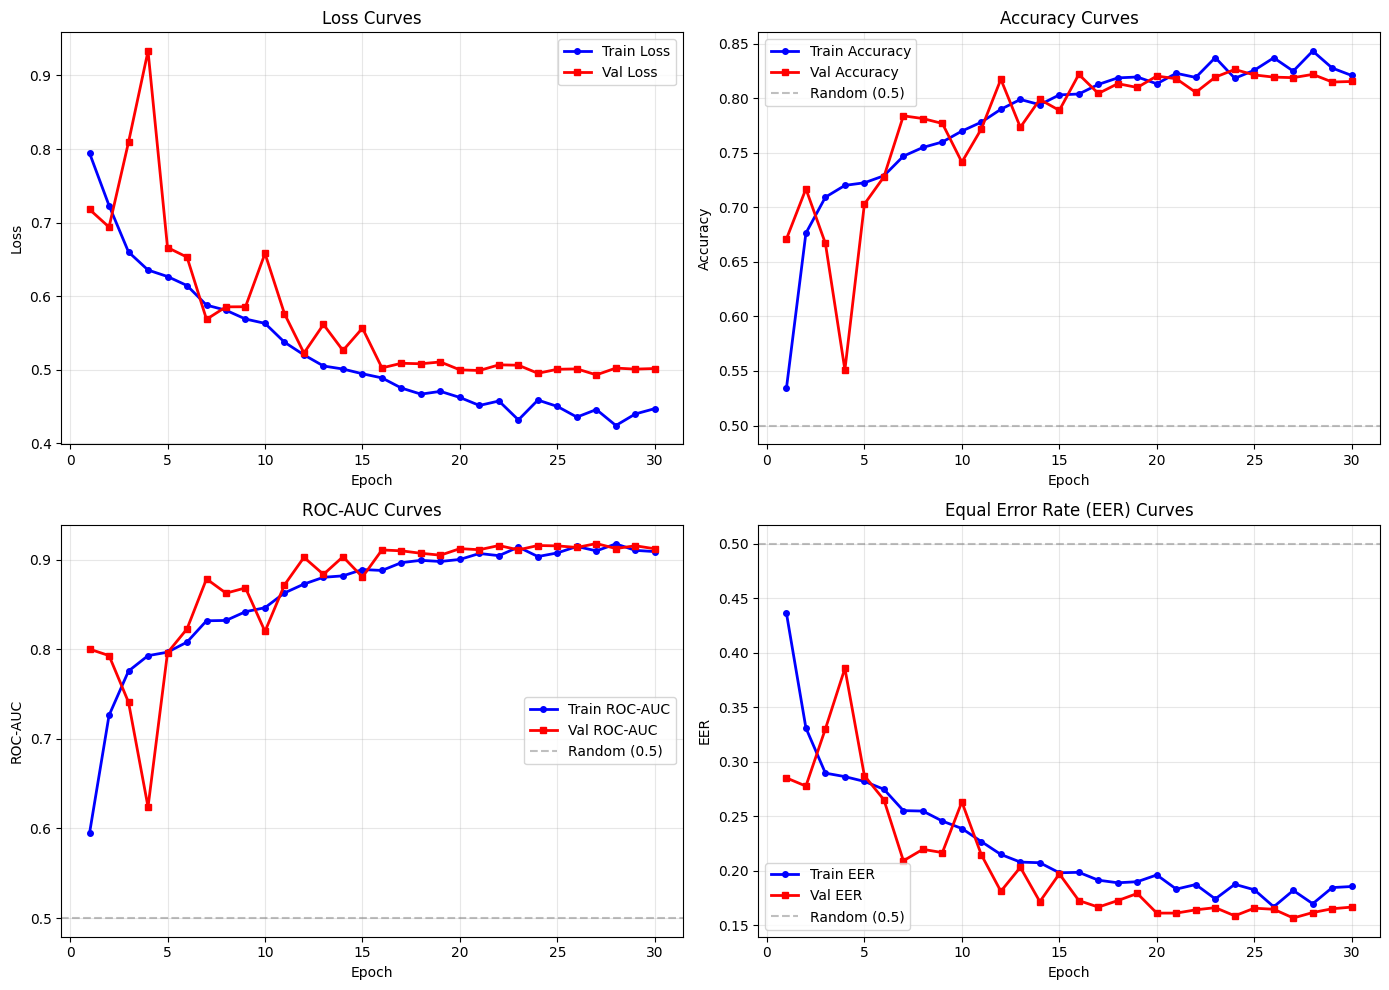

In [ ]:
epochs = range(1, len(history_agr_freezed['train_loss']) + 1)

train_loss = history_agr_freezed['train_loss']
val_loss = history_agr_freezed['val_loss']
train_acc = history_agr_freezed['train_acc']
val_acc = history_agr_freezed['val_acc']
train_roc_auc = history_agr_freezed['train_roc_auc']
val_roc_auc = history_agr_freezed['val_roc_auc']
train_eer = history_agr_freezed['train_eer']
val_eer = history_agr_freezed['val_eer']
lr = history_agr_freezed['lr']

# Create figure with 2x2 subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Loss Curves
axes[0, 0].plot(epochs, train_loss, 'b-o', label='Train Loss', linewidth=2, markersize=4)
axes[0, 0].plot(epochs, val_loss, 'r-s', label='Val Loss', linewidth=2, markersize=4)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Loss Curves')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Accuracy Curves
axes[0, 1].plot(epochs, train_acc, 'b-o', label='Train Accuracy', linewidth=2, markersize=4)
axes[0, 1].plot(epochs, val_acc, 'r-s', label='Val Accuracy', linewidth=2, markersize=4)
axes[0, 1].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Random (0.5)')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_title('Accuracy Curves')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. ROC-AUC Curves
axes[1, 0].plot(epochs, train_roc_auc, 'b-o', label='Train ROC-AUC', linewidth=2, markersize=4)
axes[1, 0].plot(epochs, val_roc_auc, 'r-s', label='Val ROC-AUC', linewidth=2, markersize=4)
axes[1, 0].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Random (0.5)')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('ROC-AUC')
axes[1, 0].set_title('ROC-AUC Curves')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. EER Curves
axes[1, 1].plot(epochs, train_eer, 'b-o', label='Train EER', linewidth=2, markersize=4)
axes[1, 1].plot(epochs, val_eer, 'r-s', label='Val EER', linewidth=2, markersize=4)
axes[1, 1].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Random (0.5)')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('EER')
axes[1, 1].set_title('Equal Error Rate (EER) Curves')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_metrics_freezed_agr_с+b.png', dpi=150, bbox_inches='tight')
plt.show()

In [38]:
def evaluate_siamese_model(model, dataloader, device):
    """
    Evaluate Siamese model on a dataloader.
    Matches exactly the evaluation logic from training.

    Args:
        model: trained SiameseNetwork model
        dataloader: DataLoader with pairs (img1, img2, label)
        device: cuda or cpu

    Returns:
        dict with metrics
    """
    model.eval()

    all_probs = []
    all_labels = []
    all_distances = []

    with torch.no_grad():
        for img1, img2, labels in dataloader:
            img1 = img1.to(device)
            img2 = img2.to(device)
            labels = labels.float().to(device)

            logits, emb1, emb2 = model(img1, img2)

            # Probability (sigmoid of logits) - same as in training
            probs = torch.sigmoid(logits)
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            # Distances for reference (not used in training metrics)
            distances = torch.norm(emb1 - emb2, p=2, dim=1)
            all_distances.extend(distances.cpu().numpy())

    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)
    all_distances = np.array(all_distances)

    # ROC-AUC on probabilities (exactly as in training)
    roc_auc = roc_auc_score(all_labels, all_probs)

    # Accuracy with fixed threshold 0.5 (exactly as in training)
    predictions = (all_probs >= 0.5).astype(int)
    accuracy = accuracy_score(all_labels, predictions)

    # EER (Equal Error Rate)
    eer = calculate_eer(all_labels, all_probs)

    # Distance statistics (for reference only)
    pos_distances = all_distances[all_labels == 1]
    neg_distances = all_distances[all_labels == 0]

    results = {
        'roc_auc': roc_auc,
        'accuracy': accuracy,
        'eer': eer,
        'mean_distance_same_author': pos_distances.mean() if len(pos_distances) > 0 else 0,
        'mean_distance_diff_author': neg_distances.mean() if len(neg_distances) > 0 else 0,
        'distance_gap': (neg_distances.mean() - pos_distances.mean()) if len(pos_distances) > 0 and len(neg_distances) > 0 else 0,
        'num_samples': len(all_labels),
        'num_positive': int((all_labels == 1).sum()),
        'num_negative': int((all_labels == 0).sum())
    }

    return results

In [ ]:
result = evaluate_siamese_model(model_agr_freezed, test_loader, device)

print(f"\nRESULTS:")
print(f"ROC-AUC: {result['roc_auc']:.4f}")
print(f"Accuracy (threshold=0.5): {result['accuracy']:.4f}")
print(f"EER: {result['eer']:.4f}")
print(f"Mean distance (positive pair): {result['mean_distance_same_author']:.4f}")
print(f"Mean distance (negative pair): {result['mean_distance_diff_author']:.4f}")
print(f"Samples: {result['num_samples']} (pos={result['num_positive']}, neg={result['num_negative']})")


RESULTS:
ROC-AUC: 0.9028
Accuracy (threshold=0.5): 0.7770
EER: 0.1949
Mean distance (positive pair): 0.1658
Mean distance (negative pair): 0.8773
Samples: 1000 (pos=536, neg=464)


In [ ]:
model_mod_freezed = SiameseNetwork(embedding_size=256, freeze_mode='moderate')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# Train
history_mod_freezed = train_model(
    model=model_mod_freezed,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=30,
    lr=0.001,
    device=device,
    save_path='best_model_mod_freezed_c+b.pth',
    weight_decay=0.0001)

print(f"\nBest Val ROC-AUC: {max(history_mod_freezed['val_roc_auc'])*100:.2f}%")

Freeze mode: moderate
Total parameters: 25,862,593
Trainable parameters: 24,427,073 (94.4%)


Epoch 1/30 [Val]: 100%|██████████| 250/250 [00:30<00:00,  8.32it/s]



Epoch 1/30
  Train Loss: 0.7980, Train Acc: 0.5488, ROC-AUC: 0.5846, EER: 0.4458
  Val Loss:   0.7832, Val Acc:   0.6620, ROC-AUC: 0.7590, EER: 0.3415
  LR: 0.001000
Model saved. Val Acc: 0.6620, Val ROC-AUC: 0.7590, Val EER: 0.3415


Epoch 2/30 [Val]: 100%|██████████| 250/250 [00:29<00:00,  8.52it/s]



Epoch 2/30
  Train Loss: 0.7434, Train Acc: 0.6406, ROC-AUC: 0.7005, EER: 0.3598
  Val Loss:   0.7872, Val Acc:   0.6115, ROC-AUC: 0.7006, EER: 0.3820
  LR: 0.001000


...


Epoch 28/30
  Train Loss: 0.4145, Train Acc: 0.8482, ROC-AUC: 0.9235, EER: 0.1608
  Val Loss:   0.5052, Val Acc:   0.7995, ROC-AUC: 0.9195, EER: 0.1545
  LR: 0.000063
Model saved. Val Acc: 0.7995, Val ROC-AUC: 0.9195, Val EER: 0.1545


Epoch 29/30 [Val]: 100%|██████████| 250/250 [00:29<00:00,  8.51it/s]



Epoch 29/30
  Train Loss: 0.4111, Train Acc: 0.8518, ROC-AUC: 0.9238, EER: 0.1586
  Val Loss:   0.5028, Val Acc:   0.7965, ROC-AUC: 0.9211, EER: 0.1645
  LR: 0.000063
Model saved. Val Acc: 0.7965, Val ROC-AUC: 0.9211, Val EER: 0.1645


Epoch 30/30 [Val]: 100%|██████████| 250/250 [00:29<00:00,  8.51it/s]



Epoch 30/30
  Train Loss: 0.4171, Train Acc: 0.8436, ROC-AUC: 0.9214, EER: 0.1618
  Val Loss:   0.4981, Val Acc:   0.7995, ROC-AUC: 0.9228, EER: 0.1620
  LR: 0.000063
Model saved. Val Acc: 0.7995, Val ROC-AUC: 0.9228, Val EER: 0.1620

Best Val ROC-AUC: 92.28%


In [ ]:
history_mod_freezed

{'train_loss': [0.7979797998428345,
  0.74339334192276,
  0.6863940181732178,
  0.6458752893924713,
  0.6246209088563919,
  0.6302756259799004,
  0.612381637430191,
  0.5925589869976043,
  0.5935554700613022,
  0.5722967609405517,
  0.5570503194093704,
  0.5473517415881157,
  0.5241874901771545,
  0.5129978863596916,
  0.5036989918828011,
  0.5043103692173958,
  0.4663488549113274,
  0.4759252032995224,
  0.46104198807477953,
  0.44116075958013534,
  0.4651721180677414,
  0.4563423869729042,
  0.4495761776447296,
  0.4334220192313194,
  0.42741798766851424,
  0.42637181061506274,
  0.43461522036790845,
  0.41448866149187086,
  0.41114036555290223,
  0.41707294744849205],
 'val_loss': [0.7832428648471832,
  0.7872214230298996,
  0.7648227463364601,
  0.6333115445375442,
  0.7297287181615829,
  0.6209985839128495,
  0.7447704089283943,
  0.5674036278128624,
  0.6150287321805954,
  0.5881388676166535,
  0.6074977222085,
  0.6134860190749168,
  0.5968779430389405,
  0.5471656726598739,
  0

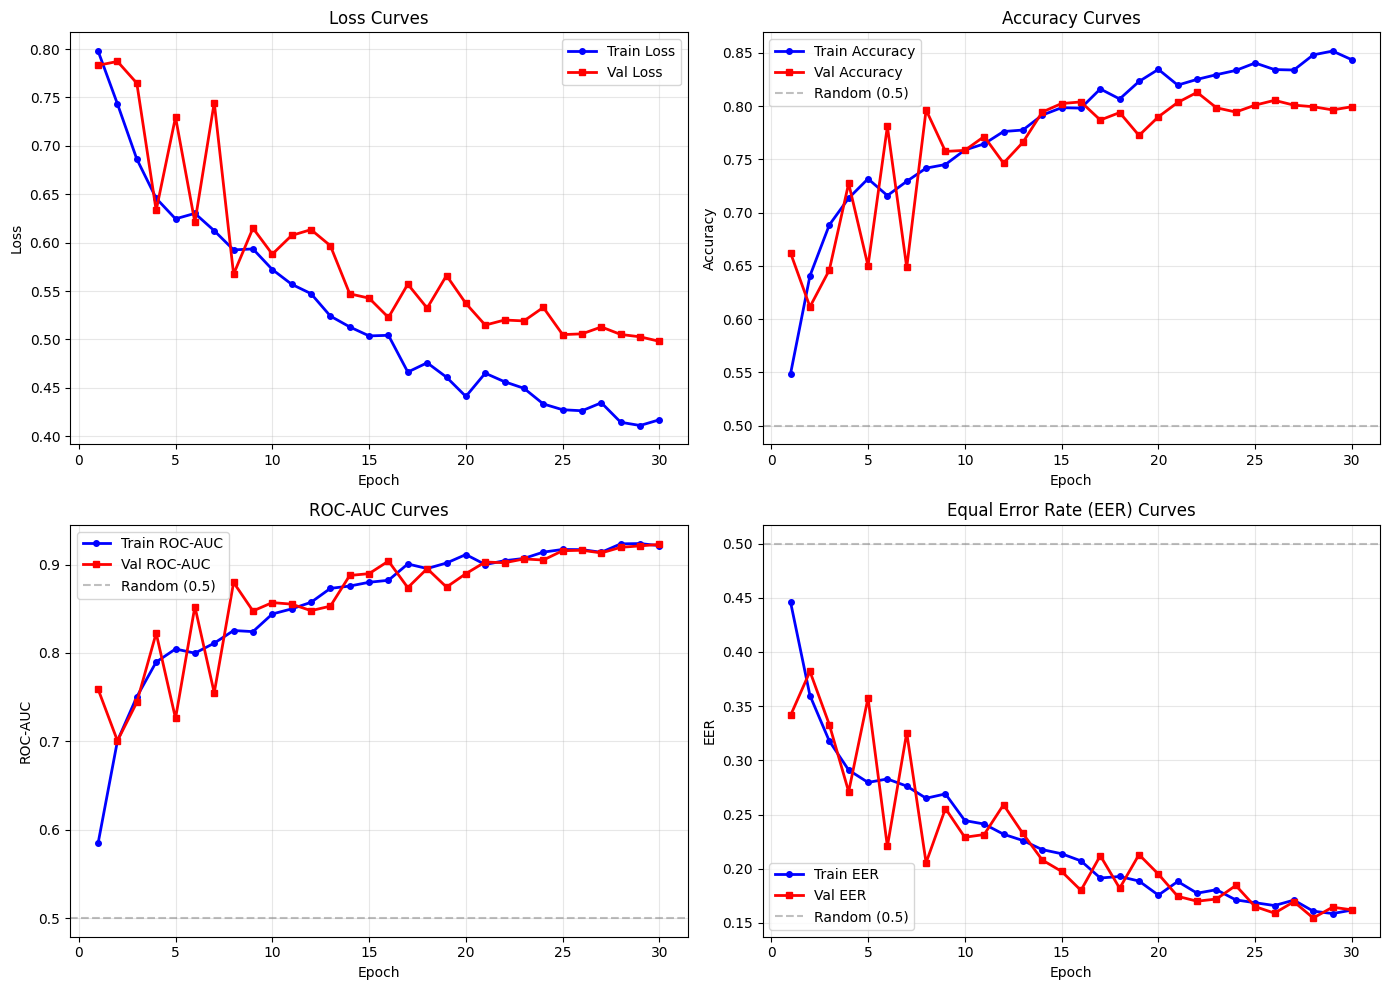

In [ ]:
epochs = range(1, len(history_mod_freezed['train_loss']) + 1)

train_loss = history_mod_freezed['train_loss']
val_loss = history_mod_freezed['val_loss']
train_acc = history_mod_freezed['train_acc']
val_acc = history_mod_freezed['val_acc']
train_roc_auc = history_mod_freezed['train_roc_auc']
val_roc_auc = history_mod_freezed['val_roc_auc']
train_eer = history_mod_freezed['train_eer']
val_eer = history_mod_freezed['val_eer']
lr = history_mod_freezed['lr']

# Create figure with 2x2 subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Loss Curves
axes[0, 0].plot(epochs, train_loss, 'b-o', label='Train Loss', linewidth=2, markersize=4)
axes[0, 0].plot(epochs, val_loss, 'r-s', label='Val Loss', linewidth=2, markersize=4)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Loss Curves')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Accuracy Curves
axes[0, 1].plot(epochs, train_acc, 'b-o', label='Train Accuracy', linewidth=2, markersize=4)
axes[0, 1].plot(epochs, val_acc, 'r-s', label='Val Accuracy', linewidth=2, markersize=4)
axes[0, 1].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Random (0.5)')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_title('Accuracy Curves')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. ROC-AUC Curves
axes[1, 0].plot(epochs, train_roc_auc, 'b-o', label='Train ROC-AUC', linewidth=2, markersize=4)
axes[1, 0].plot(epochs, val_roc_auc, 'r-s', label='Val ROC-AUC', linewidth=2, markersize=4)
axes[1, 0].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Random (0.5)')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('ROC-AUC')
axes[1, 0].set_title('ROC-AUC Curves')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. EER Curves
axes[1, 1].plot(epochs, train_eer, 'b-o', label='Train EER', linewidth=2, markersize=4)
axes[1, 1].plot(epochs, val_eer, 'r-s', label='Val EER', linewidth=2, markersize=4)
axes[1, 1].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Random (0.5)')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('EER')
axes[1, 1].set_title('Equal Error Rate (EER) Curves')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_metrics_freezed_mod_c+b.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
model_mod_freezed = model_mod_freezed.to(device)

In [ ]:
def evaluate_siamese_model(model, dataloader, device):
    """
    Evaluate Siamese model on a dataloader.
    Matches exactly the evaluation logic from training.

    Args:
        model: trained SiameseNetwork model
        dataloader: DataLoader with pairs (img1, img2, label)
        device: cuda or cpu

    Returns:
        dict with metrics
    """
    model.eval()

    all_probs = []
    all_labels = []
    all_distances = []

    with torch.no_grad():
        for img1, img2, labels in dataloader:
            img1 = img1.to(device)
            img2 = img2.to(device)
            labels = labels.float().to(device)

            logits, emb1, emb2 = model(img1, img2)

            # Probability (sigmoid of logits) - same as in training
            probs = torch.sigmoid(logits)
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            # Distances for reference (not used in training metrics)
            distances = torch.norm(emb1 - emb2, p=2, dim=1)
            all_distances.extend(distances.cpu().numpy())

    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)
    all_distances = np.array(all_distances)

    # ROC-AUC on probabilities (exactly as in training)
    roc_auc = roc_auc_score(all_labels, all_probs)

    # Accuracy with fixed threshold 0.5 (exactly as in training)
    predictions = (all_probs >= 0.5).astype(int)
    accuracy = accuracy_score(all_labels, predictions)

    # EER (Equal Error Rate)
    eer = calculate_eer(all_labels, all_probs)

    # Distance statistics (for reference only)
    pos_distances = all_distances[all_labels == 1]
    neg_distances = all_distances[all_labels == 0]

    results = {
        'roc_auc': roc_auc,
        'accuracy': accuracy,
        'eer': eer,
        'mean_distance_same_author': pos_distances.mean() if len(pos_distances) > 0 else 0,
        'mean_distance_diff_author': neg_distances.mean() if len(neg_distances) > 0 else 0,
        'distance_gap': (neg_distances.mean() - pos_distances.mean()) if len(pos_distances) > 0 and len(neg_distances) > 0 else 0,
        'num_samples': len(all_labels),
        'num_positive': int((all_labels == 1).sum()),
        'num_negative': int((all_labels == 0).sum())
    }

    return results


In [ ]:
result = evaluate_siamese_model(model_mod_freezed, test_loader, device)

print(f"\nRESULTS:")
print(f"ROC-AUC: {result['roc_auc']:.4f}")
print(f"Accuracy (threshold=0.5): {result['accuracy']:.4f}")
print(f"EER: {result['eer']:.4f}")
print(f"Mean distance (positive pair): {result['mean_distance_same_author']:.4f}")
print(f"Mean distance (negative pair): {result['mean_distance_diff_author']:.4f}")
print(f"Samples: {result['num_samples']} (pos={result['num_positive']}, neg={result['num_negative']})")


RESULTS:
ROC-AUC: 0.9214
Accuracy (threshold=0.5): 0.7990
EER: 0.1640
Mean distance (positive pair): 0.1796
Mean distance (negative pair): 0.8298
Samples: 1000 (pos=536, neg=464)


In [ ]:
model_not_freezed = SiameseNetwork(embedding_size=256, freeze_mode=None)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# Train
history_not_freezed = train_model(
    model=model_not_freezed,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=30,
    lr=0.001,
    device=device,
    save_path='best_model_not_freezed.pth',
    weight_decay=0.0001)

print(f"\nBest Val ROC-AUC: {max(history_not_freezed['val_roc_auc'])*100:.2f}%")

Freeze mode: None
Total parameters: 25,862,593
Trainable parameters: 25,862,593 (100.0%)


Epoch 1/30 [Val]: 100%|██████████| 250/250 [00:29<00:00,  8.47it/s]



Epoch 1/30
  Train Loss: 0.8028, Train Acc: 0.5464, ROC-AUC: 0.5965, EER: 0.4384
  Val Loss:   0.7759, Val Acc:   0.6900, ROC-AUC: 0.7692, EER: 0.2975
  LR: 0.001000
Model saved. Val Acc: 0.6900, Val ROC-AUC: 0.7692, Val EER: 0.2975


Epoch 2/30 [Val]: 100%|██████████| 250/250 [00:29<00:00,  8.53it/s]



Epoch 2/30
  Train Loss: 0.7494, Train Acc: 0.6352, ROC-AUC: 0.6893, EER: 0.3672
  Val Loss:   0.9110, Val Acc:   0.4935, ROC-AUC: 0.6698, EER: 0.4025
  LR: 0.001000


...


Epoch 28/30
  Train Loss: 0.4233, Train Acc: 0.8444, ROC-AUC: 0.9152, EER: 0.1584
  Val Loss:   0.4746, Val Acc:   0.8115, ROC-AUC: 0.9228, EER: 0.1590
  LR: 0.000250


Epoch 29/30 [Val]: 100%|██████████| 250/250 [00:29<00:00,  8.58it/s]



Epoch 29/30
  Train Loss: 0.4268, Train Acc: 0.8370, ROC-AUC: 0.9138, EER: 0.1728
  Val Loss:   0.4869, Val Acc:   0.7980, ROC-AUC: 0.9261, EER: 0.1525
  LR: 0.000250


Epoch 30/30 [Val]: 100%|██████████| 250/250 [00:29<00:00,  8.45it/s]


Epoch 30/30
  Train Loss: 0.4208, Train Acc: 0.8440, ROC-AUC: 0.9156, EER: 0.1652
  Val Loss:   0.4831, Val Acc:   0.8000, ROC-AUC: 0.9256, EER: 0.1480
  LR: 0.000125

Best Val ROC-AUC: 93.07%


In [ ]:
history_not_freezed

{'train_loss': [0.8028127965927124,
  0.7493596610069275,
  0.7648699088573456,
  0.7537095752239227,
  0.7855519630908966,
  0.7416922410488128,
  0.6971347333431244,
  0.6600925149202347,
  0.6555726766586304,
  0.639853855419159,
  0.6339998253345489,
  0.6132708932876587,
  0.5898891234397888,
  0.5642985243320465,
  0.552997794008255,
  0.5209619540929794,
  0.5214191798985004,
  0.5081083045363426,
  0.49312564940452575,
  0.47955728965997696,
  0.45636803377866747,
  0.4656600228905678,
  0.4502281563162804,
  0.4367313251495361,
  0.43572007871866225,
  0.4308445780992508,
  0.42467359919548037,
  0.4233319630384445,
  0.42680263845920563,
  0.4207504380941391],
 'val_loss': [0.7758785297870636,
  0.9109674961566925,
  0.7835467082262039,
  0.7325075489282608,
  0.7739740996360779,
  0.8147652351856232,
  0.6938963588476181,
  0.7462340831756592,
  0.6660874067544937,
  0.6435641691684723,
  0.595303330719471,
  0.5837519004940986,
  0.5607029614448548,
  0.7564948656558991,
  

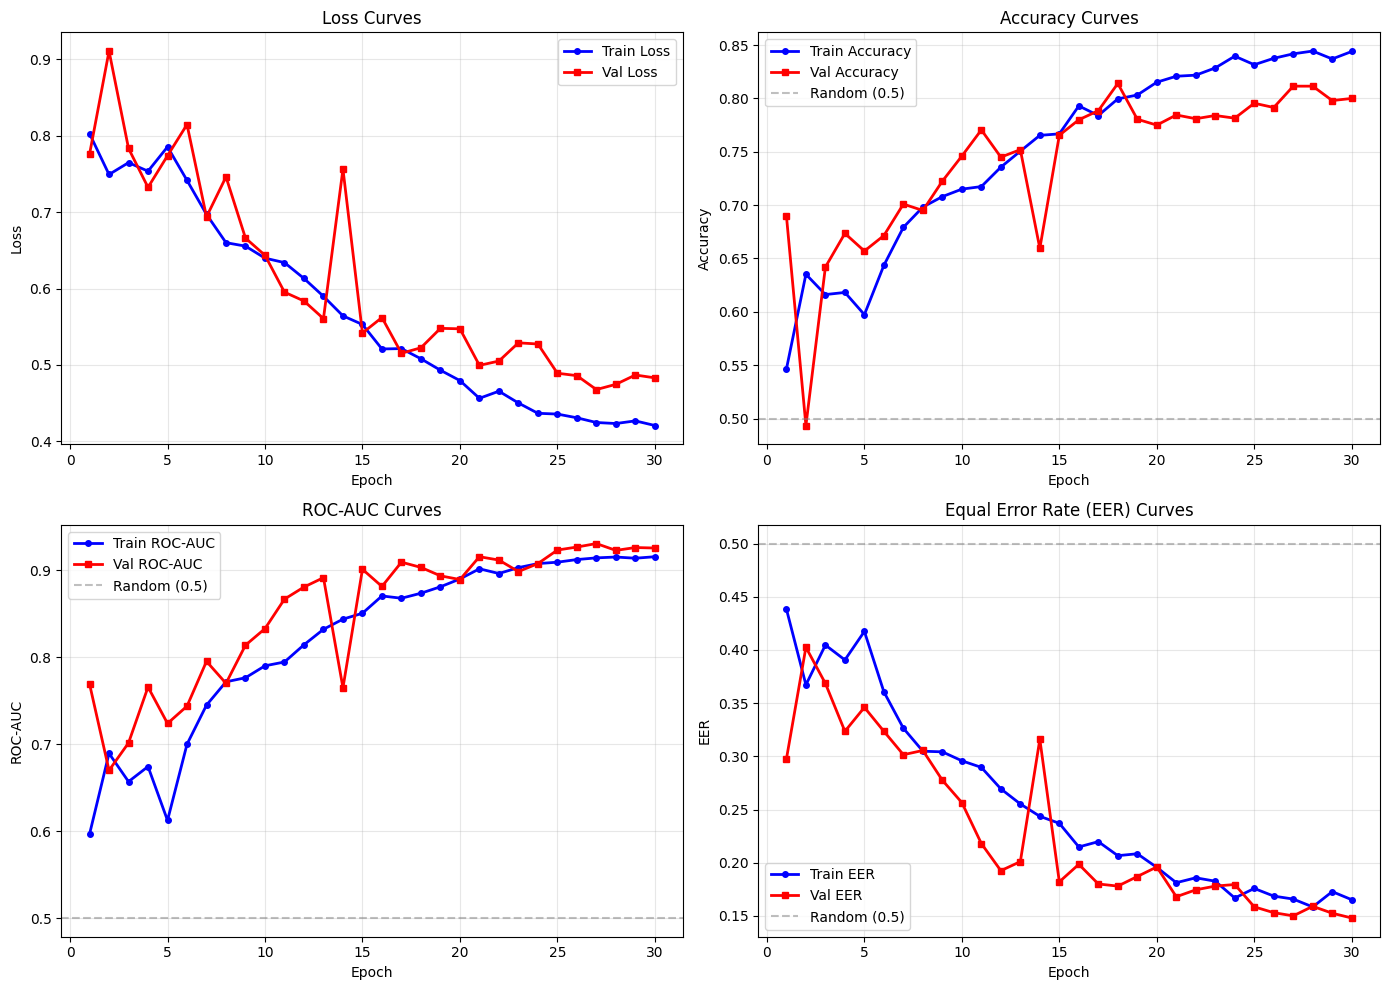

In [ ]:
epochs = range(1, len(history_not_freezed['train_loss']) + 1)

train_loss = history_not_freezed['train_loss']
val_loss = history_not_freezed['val_loss']
train_acc = history_not_freezed['train_acc']
val_acc = history_not_freezed['val_acc']
train_roc_auc = history_not_freezed['train_roc_auc']
val_roc_auc = history_not_freezed['val_roc_auc']
train_eer = history_not_freezed['train_eer']
val_eer = history_not_freezed['val_eer']
lr = history_not_freezed['lr']

# Create figure with 2x2 subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Loss Curves
axes[0, 0].plot(epochs, train_loss, 'b-o', label='Train Loss', linewidth=2, markersize=4)
axes[0, 0].plot(epochs, val_loss, 'r-s', label='Val Loss', linewidth=2, markersize=4)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Loss Curves')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Accuracy Curves
axes[0, 1].plot(epochs, train_acc, 'b-o', label='Train Accuracy', linewidth=2, markersize=4)
axes[0, 1].plot(epochs, val_acc, 'r-s', label='Val Accuracy', linewidth=2, markersize=4)
axes[0, 1].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Random (0.5)')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_title('Accuracy Curves')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. ROC-AUC Curves
axes[1, 0].plot(epochs, train_roc_auc, 'b-o', label='Train ROC-AUC', linewidth=2, markersize=4)
axes[1, 0].plot(epochs, val_roc_auc, 'r-s', label='Val ROC-AUC', linewidth=2, markersize=4)
axes[1, 0].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Random (0.5)')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('ROC-AUC')
axes[1, 0].set_title('ROC-AUC Curves')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. EER Curves
axes[1, 1].plot(epochs, train_eer, 'b-o', label='Train EER', linewidth=2, markersize=4)
axes[1, 1].plot(epochs, val_eer, 'r-s', label='Val EER', linewidth=2, markersize=4)
axes[1, 1].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Random (0.5)')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('EER')
axes[1, 1].set_title('Equal Error Rate (EER) Curves')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_metrics_not_freezed.png', dpi=150, bbox_inches='tight')
plt.show()




In [ ]:
result = evaluate_siamese_model(model_not_freezed, test_loader, device)

print(f"\nRESULTS:")
print(f"ROC-AUC: {result['roc_auc']:.4f}")
print(f"Accuracy (threshold=0.5): {result['accuracy']:.4f}")
print(f"EER: {result['eer']:.4f}")
print(f"Mean distance (positive pair): {result['mean_distance_same_author']:.4f}")
print(f"Mean distance (negative pair): {result['mean_distance_diff_author']:.4f}")
print(f"Samples: {result['num_samples']} (pos={result['num_positive']}, neg={result['num_negative']})")


RESULTS:
ROC-AUC: 0.9084
Accuracy (threshold=0.5): 0.8040
EER: 0.1559
Mean distance (positive pair): 0.1671
Mean distance (negative pair): 0.8308
Samples: 1000 (pos=536, neg=464)


In [12]:
#importing dataset

file_id = "1JJuTbRRBaCgm3UjjHnFmHOaH_vZo4zsk"
output_name = "icdar_chinese.zip"

!gdown --id {file_id} -O {output_name}

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1JJuTbRRBaCgm3UjjHnFmHOaH_vZo4zsk
From (redirected): https://drive.google.com/uc?id=1JJuTbRRBaCgm3UjjHnFmHOaH_vZo4zsk&confirm=t&uuid=17d83b4a-5c77-4781-8d98-468a9274664a
To: /content/icdar_chinese.zip
100% 405M/405M [00:05<00:00, 73.3MB/s]


In [13]:
import zipfile
import os

with zipfile.ZipFile("icdar_chinese.zip", 'r') as zip_ref:
    zip_ref.extractall("/kaggle/working/")

# Посмотрите, что получилось
os.listdir("/kaggle/working/")

['icdar_chinese', 'all_data_3']

In [14]:
DATA_ROOT_icdar_chinese = "/kaggle/working/icdar_chinese"

In [15]:
class ICDARDataset(Dataset):
    def __init__(self, root, transform=None, size=100, authors_list=None):
        """
        Dataset for ICDAR signatures with Contrastive Loss.

        Args:
            root: Root directory containing author folders with 'genuine' and 'forge' subfolders
            transform: Image transformations
            size: Number of pairs per epoch
            authors_list: List of author IDs to include (for train/val split)
        """
        self.transform = transform
        self.size = size

        # Data structures
        self.genuine_images = {}  # author_id -> list of genuine image paths
        self.forged_images = {}   # author_id -> list of forged image paths

        # Scan author folders
        for author_id in os.listdir(root):
            author_path = os.path.join(root, author_id)
            if not os.path.isdir(author_path):
                continue

            # Filter by authors_list if provided
            if authors_list is not None and author_id not in authors_list:
                continue

            # Scan genuine folder
            genuine_path = os.path.join(author_path, 'genuine')
            if os.path.exists(genuine_path):
                valid_images = []
                for file in os.listdir(genuine_path):
                    if not file.lower().endswith(('.png', '.jpg', '.jpeg')):
                        continue
                    img_path = os.path.join(genuine_path, file)
                    try:
                        with Image.open(img_path) as img:
                            img.verify()
                        valid_images.append(img_path)
                    except Exception:
                        continue
                if valid_images:
                    self.genuine_images[author_id] = valid_images

            # Scan forge folder
            forge_path = os.path.join(author_path, 'forge')
            if os.path.exists(forge_path):
                valid_images = []
                for file in os.listdir(forge_path):
                    if not file.lower().endswith(('.png', '.jpg', '.jpeg')):
                        continue
                    img_path = os.path.join(forge_path, file)
                    try:
                        with Image.open(img_path) as img:
                            img.verify()
                        valid_images.append(img_path)
                    except Exception:
                        continue
                if valid_images:
                    self.forged_images[author_id] = valid_images

        # Build author lists
        # For positive pairs: need at least 2 genuine images
        self.positive_authors = [a for a, imgs in self.genuine_images.items() if len(imgs) >= 2]

        # For negative pairs: need at least 1 genuine and 1 forged
        self.negative_authors = [a for a in self.genuine_images.keys()
                                  if a in self.forged_images
                                  and len(self.genuine_images[a]) >= 1
                                  and len(self.forged_images[a]) >= 1]

        # All authors for potential use
        self.all_authors = list(self.genuine_images.keys())

        # Print statistics
        total_genuine = sum(len(v) for v in self.genuine_images.values())
        total_forged = sum(len(v) for v in self.forged_images.values())

    def __len__(self):
        return self.size

    def _get_positive_pair(self):
        """Return two genuine signatures from same author (label=1)"""
        author = random.choice(self.positive_authors)
        images = self.genuine_images[author]
        img1_path, img2_path = random.sample(images, 2)
        return img1_path, img2_path, 1

    def _get_negative_pair(self):
        """Return genuine vs forged signature from same author (label=0)"""
        if not self.negative_authors:
            # Fallback: different authors if no forgeries available
            return self._get_different_authors_pair()

        author = random.choice(self.negative_authors)
        genuine_images = self.genuine_images[author]
        forged_images = self.forged_images[author]

        img1_path = random.choice(genuine_images)
        img2_path = random.choice(forged_images)
        return img1_path, img2_path, 0

    def _get_different_authors_pair(self):
        """Fallback: return genuine signatures from different authors (label=0)"""
        if len(self.all_authors) < 2:
            # Ultimate fallback: positive pair
            return self._get_positive_pair()

        author1, author2 = random.sample(self.all_authors, 2)
        img1_path = random.choice(self.genuine_images[author1])
        img2_path = random.choice(self.genuine_images[author2])
        return img1_path, img2_path, 0

    def __getitem__(self, idx):
        # 50% positive pairs (genuine vs genuine), 50% negative pairs (genuine vs forged)
        if random.random() < 0.5:
            img1_path, img2_path, label = self._get_positive_pair()
        else:
            img1_path, img2_path, label = self._get_negative_pair()

        # Load images
        img1 = Image.open(img1_path).convert('L')
        img2 = Image.open(img2_path).convert('L')

        if self.transform:
            img1 = self.transform(img1)
            img2 = self.transform(img2)

        return img1, img2, label, img1_path, img2_path

In [16]:
# # Создание и сохранение
# icdar_chinese_pairs = []
# temp_dataset_icdar_chinese = ICDARDataset(root=DATA_ROOT_icdar_chinese, transform=None,
#                               size=5000)

# for i in range(len(temp_dataset_icdar_chinese)):
#     img1, img2, label, p1, p2 = temp_dataset_icdar_chinese[i]
#     icdar_chinese_pairs.append((p1, p2, label))

# with open('icdar_chinese_pairs.pkl', 'wb') as f:
#     pickle.dump(icdar_chinese_pairs, f)

test_icdar_chinese_dataset = SavedPairsDataset('icdar_chinese_pairs.pkl', transform=test_transform)

In [ ]:
labels_icdar_chinese=[]

for i in range(len(test_icdar_chinese_dataset)):
  labels_icdar_chinese.append(test_icdar_chinese_dataset[i][2])

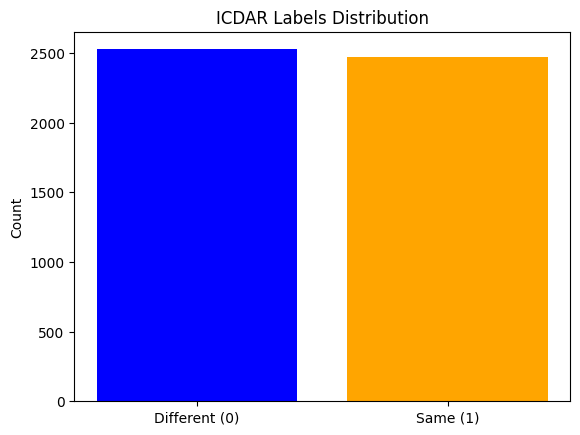

In [ ]:
counts = [labels_icdar_chinese.count(0), labels_icdar_chinese.count(1)]

plt.bar(['Different (0)', 'Same (1)'], counts, color=['blue', 'orange'])
plt.ylabel('Count')
plt.title('ICDAR Labels Distribution')
plt.show()

In [32]:
test_icdar_chinese_loader = DataLoader(
    dataset=test_icdar_chinese_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

Label: 1, /kaggle/working/icdar_chinese/013/genuine/04_013.png, /kaggle/working/icdar_chinese/013/genuine/01_013.png
Size img1: torch.Size([1, 224, 224])
Size img2: torch.Size([1, 224, 224])


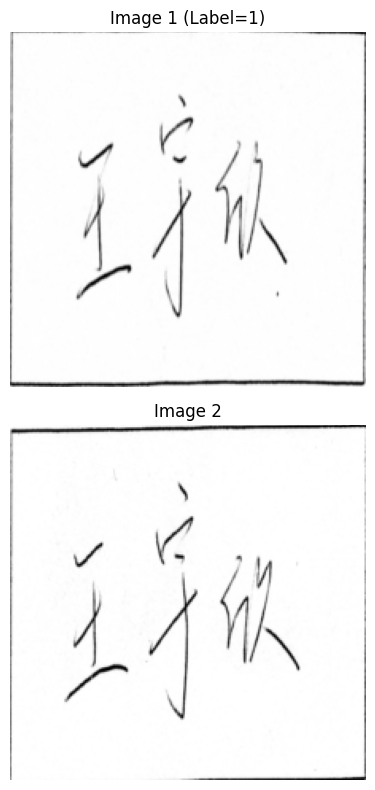

In [ ]:
img1, img2, label = test_icdar_chinese_dataset[5]

print(f"Label: {label}, {p1}, {p2}")
print(f"Size img1: {img1.shape}")
print(f"Size img2: {img2.shape}")

plt.figure(figsize=(10, 8))

plt.subplot(2, 1, 1)
plt.imshow(img1[0], cmap='gray')
plt.title(f"Image 1 (Label={label})")
plt.axis('off')

plt.subplot(2, 1, 2)
plt.imshow(img2[0], cmap='gray')
plt.title("Image 2")
plt.axis('off')

plt.tight_layout()
plt.show()

In [17]:
#importing dataset

file_id = "1R3EIjJEl2Fib0zFuacCJrTbR19x5ESoK"
output_name = "icdar_dutch.zip"

!gdown --id {file_id} -O {output_name}

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1R3EIjJEl2Fib0zFuacCJrTbR19x5ESoK
From (redirected): https://drive.google.com/uc?id=1R3EIjJEl2Fib0zFuacCJrTbR19x5ESoK&confirm=t&uuid=6fddb3f0-5bf3-4e07-bea2-dbce5d03443f
To: /content/icdar_dutch.zip
100% 388M/388M [00:06<00:00, 60.0MB/s]


In [18]:
with zipfile.ZipFile("icdar_dutch.zip", 'r') as zip_ref:
    zip_ref.extractall("/kaggle/working/")

# Посмотрите, что получилось
os.listdir("/kaggle/working/")

['icdar_chinese', 'icdar_dutch', 'all_data_3']

In [19]:
DATA_ROOT_icdar_dutch = "/kaggle/working/icdar_dutch"

In [20]:
# # Создание и сохранение
# icdar_dutch_pairs = []
# temp_dataset_icdar_dutch = ICDARDataset(root=DATA_ROOT_icdar_dutch, transform=None,
#                               size=5000)

# for i in range(len(temp_dataset_icdar_dutch)):
#     img1, img2, label, p1, p2 = temp_dataset_icdar_dutch[i]
#     icdar_dutch_pairs.append((p1, p2, label))

# with open('icdar_dutch_pairs.pkl', 'wb') as f:
#     pickle.dump(icdar_dutch_pairs, f)

test_icdar_dutch_dataset = SavedPairsDataset('icdar_dutch_pairs.pkl', transform=test_transform)

In [ ]:
labels_icdar_dutch=[]

for i in range(len(test_icdar_dutch_dataset)):
  labels_icdar_dutch.append(test_icdar_dutch_dataset[i][2])

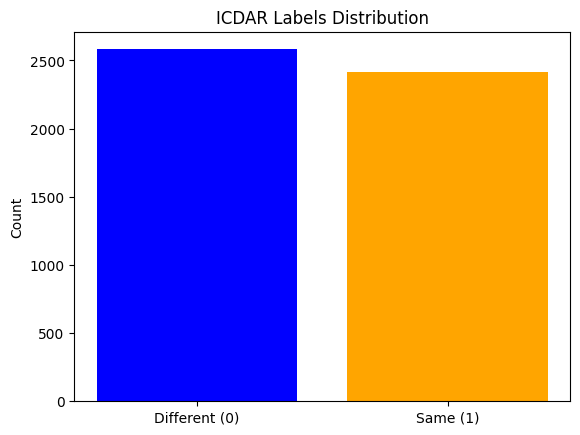

In [ ]:
counts = [labels_icdar_dutch.count(0), labels_icdar_dutch.count(1)]

plt.bar(['Different (0)', 'Same (1)'], counts, color=['blue', 'orange'])
plt.ylabel('Count')
plt.title('ICDAR Labels Distribution')
plt.show()

In [21]:
test_icdar_dutch_loader = DataLoader(
    dataset=test_icdar_dutch_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

Label: 0, /kaggle/working/icdar_dutch/043/genuine/24_043.PNG, /kaggle/working/icdar_dutch/043/forge/04_0111043.PNG
Size img1: torch.Size([1, 224, 224])
Size img2: torch.Size([1, 224, 224])


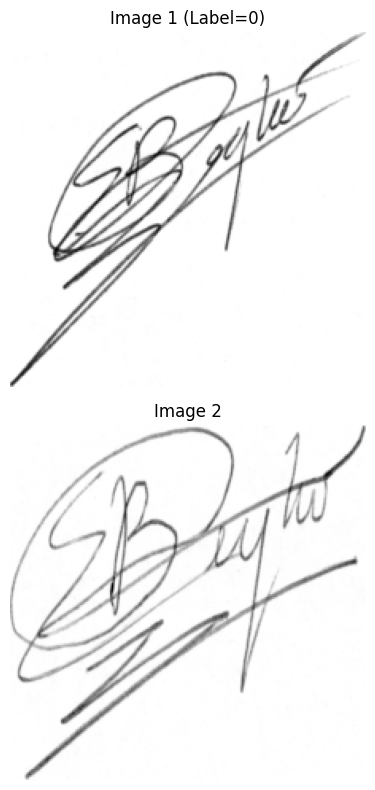

In [ ]:
img1, img2, label = test_icdar_dutch_dataset[1]

print(f"Label: {label}, {p1}, {p2}")
print(f"Size img1: {img1.shape}")
print(f"Size img2: {img2.shape}")

plt.figure(figsize=(10, 8))

plt.subplot(2, 1, 1)
plt.imshow(img1[0], cmap='gray')
plt.title(f"Image 1 (Label={label})")
plt.axis('off')

plt.subplot(2, 1, 2)
plt.imshow(img2[0], cmap='gray')
plt.title("Image 2")
plt.axis('off')

plt.tight_layout()
plt.show()

In [28]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [29]:
checkpoint_agr_c_b = torch.load('best_model_agr_freezed_c+b.pth', map_location='cpu', weights_only=False)
checkpoint_mod_c_b = torch.load('best_model_mod_freezed_c+b.pth', map_location='cpu', weights_only=False)
checkpoint_none_c_b = torch.load('best_model_not_freezed_c+b.pth', map_location='cpu', weights_only=False)

In [30]:
model_agr_c_b = SiameseNetwork(embedding_size=256, freeze_mode='aggressive')
model_agr_c_b.load_state_dict(checkpoint_agr_c_b['model_state_dict'])
model_agr_c_b.eval()

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 187MB/s]


Freeze mode: aggressive
Total parameters: 25,862,593
Trainable parameters: 17,328,705 (67.0%)


SiameseNetwork(
  (resnet): Sequential(
    (0): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
          (0): Conv2

In [31]:
model_agr_c_b=model_agr_c_b.to(device)

In [32]:
model_mod_c_b = SiameseNetwork(embedding_size=256, freeze_mode='moderate')
model_mod_c_b.load_state_dict(checkpoint_mod_c_b['model_state_dict'])
model_mod_c_b.eval()

Freeze mode: moderate
Total parameters: 25,862,593
Trainable parameters: 24,427,073 (94.4%)


SiameseNetwork(
  (resnet): Sequential(
    (0): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
          (0): Conv2

In [33]:
model_mod_c_b=model_mod_c_b.to(device)

In [34]:
model_none_c_b = SiameseNetwork(embedding_size=256, freeze_mode=None)
model_none_c_b.load_state_dict(checkpoint_none_c_b['model_state_dict'])
model_none_c_b.eval()

Freeze mode: None
Total parameters: 25,862,593
Trainable parameters: 25,862,593 (100.0%)


SiameseNetwork(
  (resnet): Sequential(
    (0): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
          (0): Conv2

In [35]:
model_none_c_b=model_none_c_b.to(device)

In [ ]:
result_icdar_chinese_agr_c_b = evaluate_siamese_model(model_agr_c_b, test_icdar_chinese_loader, device)

print(f"\nRESULTS:")
print(f"ROC-AUC: {result_icdar_chinese_agr_c_b['roc_auc']:.4f}")
print(f"Accuracy (threshold=0.5): {result_icdar_chinese_agr_c_b['accuracy']:.4f}")
print(f"EER: {result_icdar_chinese_agr_c_b['eer']:.4f}")
print(f"Mean distance (positive pair): {result_icdar_chinese_agr_c_b['mean_distance_same_author']:.4f}")
print(f"Mean distance (negative pair): {result_icdar_chinese_agr_c_b['mean_distance_diff_author']:.4f}")
print(f"Samples: {result_icdar_chinese_agr_c_b['num_samples']} (pos={result_icdar_chinese_agr_c_b['num_positive']}, neg={result_icdar_chinese_agr_c_b['num_negative']})")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



RESULTS:
ROC-AUC: 0.5764
Accuracy (threshold=0.5): 0.5476
EER: 0.4440
Mean distance (positive pair): 0.1707
Mean distance (negative pair): 0.2244
Samples: 5000 (pos=2473, neg=2527)


In [ ]:
result_icdar_dutch_agr_c_b = evaluate_siamese_model(model_agr_c_b, test_icdar_dutch_loader, device)

print(f"\nRESULTS:")
print(f"ROC-AUC: {result_icdar_dutch_agr_c_b['roc_auc']:.4f}")
print(f"Accuracy (threshold=0.5): {result_icdar_dutch_agr_c_b['accuracy']:.4f}")
print(f"EER: {result_icdar_dutch_agr_c_b['eer']:.4f}")
print(f"Mean distance (positive pair): {result_icdar_dutch_agr_c_b['mean_distance_same_author']:.4f}")
print(f"Mean distance (negative pair): {result_icdar_dutch_agr_c_b['mean_distance_diff_author']:.4f}")
print(f"Samples: {result_icdar_dutch_agr_c_b['num_samples']} (pos={result_icdar_dutch_agr_c_b['num_positive']}, neg={result_icdar_dutch_agr_c_b['num_negative']})")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



RESULTS:
ROC-AUC: 0.6179
Accuracy (threshold=0.5): 0.5746
EER: 0.4180
Mean distance (positive pair): 0.3234
Mean distance (negative pair): 0.4736
Samples: 5000 (pos=2418, neg=2582)


In [ ]:
result_icdar_chinese_mod_c_b = evaluate_siamese_model(model_mod_c_b, test_icdar_chinese_loader, device)

print(f"\nRESULTS:")
print(f"ROC-AUC: {result_icdar_chinese_mod_c_b['roc_auc']:.4f}")
print(f"Accuracy (threshold=0.5): {result_icdar_chinese_mod_c_b['accuracy']:.4f}")
print(f"EER: {result_icdar_chinese_mod_c_b['eer']:.4f}")
print(f"Mean distance (positive pair): {result_icdar_chinese_mod_c_b['mean_distance_same_author']:.4f}")
print(f"Mean distance (negative pair): {result_icdar_chinese_mod_c_b['mean_distance_diff_author']:.4f}")
print(f"Samples: {result_icdar_chinese_mod_c_b['num_samples']} (pos={result_icdar_chinese_mod_c_b['num_positive']}, neg={result_icdar_chinese_mod_c_b['num_negative']})")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



RESULTS:
ROC-AUC: 0.6298
Accuracy (threshold=0.5): 0.5900
EER: 0.4098
Mean distance (positive pair): 0.2007
Mean distance (negative pair): 0.2750
Samples: 5000 (pos=2473, neg=2527)


In [30]:
result_icdar_dutch_mod_c_b = evaluate_siamese_model(model_mod_c_b, test_icdar_dutch_loader, device)

print(f"\nRESULTS:")
print(f"ROC-AUC: {result_icdar_dutch_mod_c_b['roc_auc']:.4f}")
print(f"Accuracy (threshold=0.5): {result_icdar_dutch_mod_c_b['accuracy']:.4f}")
print(f"EER: {result_icdar_dutch_mod_c_b['eer']:.4f}")
print(f"Mean distance (positive pair): {result_icdar_dutch_mod_c_b['mean_distance_same_author']:.4f}")
print(f"Mean distance (negative pair): {result_icdar_dutch_mod_c_b['mean_distance_diff_author']:.4f}")
print(f"Samples: {result_icdar_dutch_mod_c_b['num_samples']} (pos={result_icdar_dutch_mod_c_b['num_positive']}, neg={result_icdar_dutch_mod_c_b['num_negative']})")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



RESULTS:
ROC-AUC: 0.7314
Accuracy (threshold=0.5): 0.6620
EER: 0.3296
Mean distance (positive pair): 0.2138
Mean distance (negative pair): 0.3675
Samples: 5000 (pos=2418, neg=2582)


In [33]:
result_icdar_chinese_none_c_b = evaluate_siamese_model(model_none_c_b, test_icdar_chinese_loader, device)

print(f"\nRESULTS:")
print(f"ROC-AUC: {result_icdar_chinese_none_c_b['roc_auc']:.4f}")
print(f"Accuracy (threshold=0.5): {result_icdar_chinese_none_c_b['accuracy']:.4f}")
print(f"EER: {result_icdar_chinese_none_c_b['eer']:.4f}")
print(f"Mean distance (positive pair): {result_icdar_chinese_none_c_b['mean_distance_same_author']:.4f}")
print(f"Mean distance (negative pair): {result_icdar_chinese_none_c_b['mean_distance_diff_author']:.4f}")
print(f"Samples: {result_icdar_chinese_none_c_b['num_samples']} (pos={result_icdar_chinese_none_c_b['num_positive']}, neg={result_icdar_chinese_none_c_b['num_negative']})")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



RESULTS:
ROC-AUC: 0.6601
Accuracy (threshold=0.5): 0.6222
EER: 0.3810
Mean distance (positive pair): 0.2057
Mean distance (negative pair): 0.3054
Samples: 5000 (pos=2473, neg=2527)


In [34]:
result_icdar_dutch_none_c_b = evaluate_siamese_model(model_none_c_b, test_icdar_dutch_loader, device)

print(f"\nRESULTS:")
print(f"ROC-AUC: {result_icdar_dutch_none_c_b['roc_auc']:.4f}")
print(f"Accuracy (threshold=0.5): {result_icdar_dutch_none_c_b['accuracy']:.4f}")
print(f"EER: {result_icdar_dutch_none_c_b['eer']:.4f}")
print(f"Mean distance (positive pair): {result_icdar_dutch_none_c_b['mean_distance_same_author']:.4f}")
print(f"Mean distance (negative pair): {result_icdar_dutch_none_c_b['mean_distance_diff_author']:.4f}")
print(f"Samples: {result_icdar_dutch_none_c_b['num_samples']} (pos={result_icdar_dutch_none_c_b['num_positive']}, neg={result_icdar_dutch_none_c_b['num_negative']})")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



RESULTS:
ROC-AUC: 0.8405
Accuracy (threshold=0.5): 0.7690
EER: 0.2316
Mean distance (positive pair): 0.1398
Mean distance (negative pair): 0.5240
Samples: 5000 (pos=2418, neg=2582)


In [3]:
file_id = "17qUpD1PYlT3d4MkZ6OXeIhb8gqD5F0mZ"
output_name = "cvl.zip"

!gdown --id {file_id} -O {output_name}

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=17qUpD1PYlT3d4MkZ6OXeIhb8gqD5F0mZ
From (redirected): https://drive.google.com/uc?id=17qUpD1PYlT3d4MkZ6OXeIhb8gqD5F0mZ&confirm=t&uuid=6b3d9569-60c8-4916-9236-ec38753c0e00
To: /content/cvl.zip
100% 277M/277M [00:10<00:00, 25.2MB/s]


In [5]:
import zipfile
import os

with zipfile.ZipFile("cvl.zip", 'r') as zip_ref:
    zip_ref.extractall("/kaggle/working/")

# Посмотрите, что получилось
os.listdir("/kaggle/working/")

['cvl']

In [13]:
DATA_ROOT_cvl = "/kaggle/working/cvl"

In [15]:
class CVLDataset(Dataset):
    def __init__(self, root, transform=None, size=100, authors_list=None):
        """
        Dataset for CVL handwriting images.

        Args:
            root: Root directory containing author folders with .tif images
            transform: Image transformations
            size: Number of pairs per epoch
            authors_list: List of author IDs to include (for train/val split)
        """
        self.transform = transform
        self.size = size

        # Data structure: author_id -> list of image paths
        self.author_images = {}

        # Scan author folders
        for author_id in os.listdir(root):
            author_path = os.path.join(root, author_id)
            if not os.path.isdir(author_path):
                continue

            # Filter by authors_list if provided
            if authors_list is not None and author_id not in authors_list:
                continue

            valid_images = []
            for file in os.listdir(author_path):
                if not file.lower().endswith(('.tif', '.tiff', '.png', '.jpg', '.jpeg')):
                    continue

                img_path = os.path.join(author_path, file)
                try:
                    with Image.open(img_path) as img:
                        img.verify()
                    valid_images.append(img_path)
                except Exception:
                    continue

            if valid_images:
                self.author_images[author_id] = valid_images

        # Build author lists
        # For positive pairs: need at least 2 images per author
        self.positive_authors = [a for a, imgs in self.author_images.items() if len(imgs) >= 2]

        # All authors for negative sampling
        self.all_authors = list(self.author_images.keys())

    def __len__(self):
        return self.size

    def _get_positive_pair(self):
        """Return two images from same author (label=1)"""
        author = random.choice(self.positive_authors)
        images = self.author_images[author]
        img1_path, img2_path = random.sample(images, 2)
        label = 1
        return img1_path, img2_path, label

    def _get_negative_pair(self):
        """Return images from two different authors (label=0)"""
        author1, author2 = random.sample(self.all_authors, 2)
        img1_path = random.choice(self.author_images[author1])
        img2_path = random.choice(self.author_images[author2])
        label = 0
        return img1_path, img2_path, label

    def __getitem__(self, idx):
        # 50% positive pairs, 50% negative pairs
        if random.random() < 0.5:
            img1_path, img2_path, label = self._get_positive_pair()
        else:
            img1_path, img2_path, label = self._get_negative_pair()

        # Load images
        img1 = Image.open(img1_path).convert('L')
        img2 = Image.open(img2_path).convert('L')

        if self.transform:
            img1 = self.transform(img1)
            img2 = self.transform(img2)

        return img1, img2, label, img1_path, img2_path

In [23]:
# # Создание и сохранение
cvl_pairs = []
temp_dataset_cvl = CVLDataset(root=DATA_ROOT_cvl, transform=None,
                              size=5000)

for i in range(len(temp_dataset_cvl)):
    img1, img2, label, p1, p2 = temp_dataset_cvl[i]
    cvl_pairs.append((p1, p2, label))

with open('cvl_pairs.pkl', 'wb') as f:
    pickle.dump(cvl_pairs, f)

test_cvl_dataset = SavedPairsDataset('cvl_pairs.pkl', transform=test_transform)

Label: 1
Size img1: torch.Size([1, 224, 224])
Size img2: torch.Size([1, 224, 224])


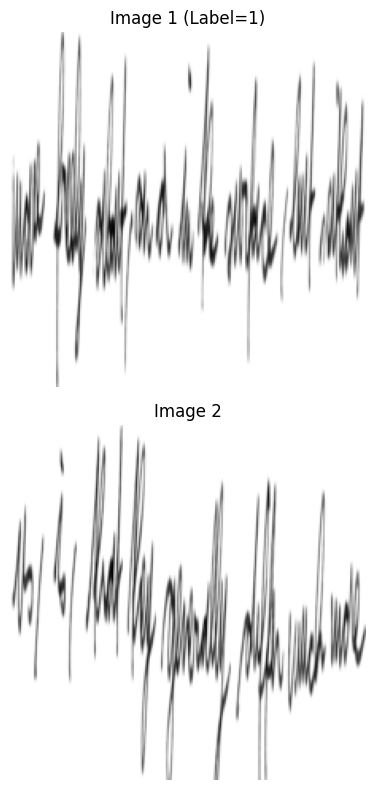

In [27]:
img1, img2, label = test_cvl_dataset[0]

print(f"Label: {label}")
print(f"Size img1: {img1.shape}")
print(f"Size img2: {img2.shape}")

plt.figure(figsize=(10, 8))

plt.subplot(2, 1, 1)
plt.imshow(img1[0], cmap='gray')
plt.title(f"Image 1 (Label={label})")
plt.axis('off')

plt.subplot(2, 1, 2)
plt.imshow(img2[0], cmap='gray')
plt.title("Image 2")
plt.axis('off')

plt.tight_layout()
plt.show()

In [36]:
test_cvl_loader = DataLoader(
    dataset=test_cvl_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

In [39]:
result_cvl_agr_c_b = evaluate_siamese_model(model_agr_c_b, test_cvl_loader, device)

print(f"\nRESULTS:")
print(f"ROC-AUC: {result_cvl_agr_c_b['roc_auc']:.4f}")
print(f"Accuracy (threshold=0.5): {result_cvl_agr_c_b['accuracy']:.4f}")
print(f"EER: {result_cvl_agr_c_b['eer']:.4f}")
print(f"Mean distance (positive pair): {result_cvl_agr_c_b['mean_distance_same_author']:.4f}")
print(f"Mean distance (negative pair): {result_cvl_agr_c_b['mean_distance_diff_author']:.4f}")
print(f"Samples: {result_cvl_agr_c_b['num_samples']} (pos={result_cvl_agr_c_b['num_positive']}, neg={result_cvl_agr_c_b['num_negative']})")


RESULTS:
ROC-AUC: 0.5486
Accuracy (threshold=0.5): 0.5108
EER: 0.4618
Mean distance (positive pair): 0.0599
Mean distance (negative pair): 0.0699
Samples: 5000 (pos=2546, neg=2454)


In [40]:
result_cvl_mod_c_b = evaluate_siamese_model(model_mod_c_b, test_cvl_loader, device)

print(f"\nRESULTS:")
print(f"ROC-AUC: {result_cvl_mod_c_b['roc_auc']:.4f}")
print(f"Accuracy (threshold=0.5): {result_cvl_mod_c_b['accuracy']:.4f}")
print(f"EER: {result_cvl_mod_c_b['eer']:.4f}")
print(f"Mean distance (positive pair): {result_cvl_mod_c_b['mean_distance_same_author']:.4f}")
print(f"Mean distance (negative pair): {result_cvl_mod_c_b['mean_distance_diff_author']:.4f}")
print(f"Samples: {result_cvl_mod_c_b['num_samples']} (pos={result_cvl_mod_c_b['num_positive']}, neg={result_cvl_mod_c_b['num_negative']})")


RESULTS:
ROC-AUC: 0.6213
Accuracy (threshold=0.5): 0.5298
EER: 0.4096
Mean distance (positive pair): 0.0625
Mean distance (negative pair): 0.0986
Samples: 5000 (pos=2546, neg=2454)


In [41]:
result_cvl_none_c_b = evaluate_siamese_model(model_none_c_b, test_cvl_loader, device)

print(f"\nRESULTS:")
print(f"ROC-AUC: {result_cvl_none_c_b['roc_auc']:.4f}")
print(f"Accuracy (threshold=0.5): {result_cvl_none_c_b['accuracy']:.4f}")
print(f"EER: {result_cvl_none_c_b['eer']:.4f}")
print(f"Mean distance (positive pair): {result_cvl_none_c_b['mean_distance_same_author']:.4f}")
print(f"Mean distance (negative pair): {result_cvl_none_c_b['mean_distance_diff_author']:.4f}")
print(f"Samples: {result_cvl_none_c_b['num_samples']} (pos={result_cvl_none_c_b['num_positive']}, neg={result_cvl_none_c_b['num_negative']})")


RESULTS:
ROC-AUC: 0.6530
Accuracy (threshold=0.5): 0.5982
EER: 0.3920
Mean distance (positive pair): 0.1116
Mean distance (negative pair): 0.2368
Samples: 5000 (pos=2546, neg=2454)
